# 13 - Phase 4 Duration Sweep

Sequentially executes notebook 12 for each target battery duration, then aggregates
and compares results across durations.

**Duration parameter** is injected via the `NB12_DURATION_H` environment variable.
Notebook 12 reads this at startup; no manual edits to nb12 are needed.

**Output files produced per duration** (by notebook 12):
- `data/processed/phase4_method_comparison_{d}h.csv` / `.json`
- `data/processed/lsmc_attribution_{d}h.json` / `.png`
- `data/processed/phase4_method_comparison_{d}h.png`
- `data/processed/executed/12_phase4_{d}h.ipynb` (executed notebook copy)

**Aggregated outputs** (produced by this notebook):
- `data/processed/phase4_all_durations_comparison.csv` / `.json`
- `data/processed/phase4_all_durations_attribution.csv` / `.json`
- `data/processed/phase4_all_durations_comparison.png`
- `data/processed/phase4_all_durations_attribution.png`


## 1  Setup


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
EXECUTED_DIR = PROCESSED / 'executed'
EXECUTED_DIR.mkdir(parents=True, exist_ok=True)

NB12_PATH = NOTEBOOKS_DIR / '12_phase4_method_comparison.ipynb'

# ── Sweep configuration ──────────────────────────────────────────────────────
SWEEP_DURATIONS_H = [1.0, 2.0, 3.0, 4.0]
TIMEOUT_S = 10_800   # 3 h per duration; increase if LSMC backward is slow

print(f'Project root : {PROJECT_ROOT}')
print(f'Notebook 12  : {NB12_PATH}  (exists={NB12_PATH.exists()})')
print(f'Executed dir : {EXECUTED_DIR}')
print(f'Durations    : {SWEEP_DURATIONS_H}')
print(f'Timeout/run  : {TIMEOUT_S/3600:.1f} h')


Project root : g:\My Drive\Research\bess_project
Notebook 12  : g:\My Drive\Research\bess_project\notebooks\12_phase4_method_comparison.ipynb  (exists=True)
Executed dir : g:\My Drive\Research\bess_project\data\processed\executed
Durations    : [1.0, 2.0, 3.0, 4.0]
Timeout/run  : 3.0 h


## 2  Sequential Execution


In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def _run_one_duration(dur: float) -> tuple[str, dict]:
    label   = f'{dur:g}h'
    out_nb  = EXECUTED_DIR / f'12_phase4_{label}.ipynb'
    csv_out = PROCESSED / f'phase4_method_comparison_{label}.csv'

    if csv_out.exists() and out_nb.exists():
        print(f'[{label}] outputs exist — skipping (delete to re-run)')
        return label, {'status': 'skipped', 'elapsed_s': 0}

    print(f'[{label}] Starting  {pd.Timestamp.now().strftime("%H:%M:%S")}')
    t0 = time.time()

    env = os.environ.copy()
    env['NB12_DURATION_H'] = str(dur)

    proc = subprocess.run(
        [
            sys.executable, '-m', 'jupyter', 'nbconvert',
            '--to', 'notebook',
            '--execute',
            f'--ExecutePreprocessor.timeout={TIMEOUT_S}',
            f'--output={out_nb}',
            str(NB12_PATH),
        ],
        env=env,
        capture_output=True,
        text=True,
    )

    elapsed = time.time() - t0
    status  = 'ok' if proc.returncode == 0 else 'failed'

    if proc.returncode == 0:
        print(f'[{label}] DONE in {elapsed/60:.1f} min  →  {out_nb.name}')
    else:
        print(f'[{label}] FAILED (rc={proc.returncode}) after {elapsed/60:.1f} min')
        print(f'--- stderr (last 3000 chars) ---')
        print(proc.stderr[-3000:])
        print('--- stdout (last 1000 chars) ---')
        print(proc.stdout[-1000:])

    return label, {
        'status':     status,
        'elapsed_s':  round(elapsed, 1),
        'output_nb':  str(out_nb),
        'returncode': proc.returncode,
    }


# Run all durations in parallel — each is a separate subprocess on its own core.
# Wall-clock time ≈ slowest single duration instead of sum of all durations.
print(f'Launching {len(SWEEP_DURATIONS_H)} durations in parallel...\n')
t_sweep_start = time.time()

run_log = {}
with ThreadPoolExecutor(max_workers=len(SWEEP_DURATIONS_H)) as pool:
    futures = {pool.submit(_run_one_duration, dur): dur for dur in SWEEP_DURATIONS_H}
    for fut in as_completed(futures):
        label, result = fut.result()
        run_log[label] = result

print(f'\n\nRun summary  (total wall-clock: {(time.time()-t_sweep_start)/60:.1f} min):')
for label in [f'{d:g}h' for d in SWEEP_DURATIONS_H]:
    r = run_log.get(label, {})
    mins = r.get('elapsed_s', 0) / 60
    print(f'  {label:5s}  {r.get("status","?"):8s}  {mins:.1f} min')

# Save run log
with open(PROCESSED / 'phase4_sweep_run_log.json', 'w') as f:
    json.dump(run_log, f, indent=2)
print('Saved: phase4_sweep_run_log.json')


## 3  Load and Aggregate Results


In [3]:
all_comparison  = []
all_attribution = []
missing = []

for dur in SWEEP_DURATIONS_H:
    label = f'{dur:g}h'

    csv_path = PROCESSED / f'phase4_method_comparison_{label}.csv'
    if csv_path.exists():
        all_comparison.append(pd.read_csv(csv_path))
        print(f'  loaded {csv_path.name}')
    else:
        missing.append(str(csv_path.name))
        print(f'  MISSING {csv_path.name}')

    attr_path = PROCESSED / f'lsmc_attribution_{label}.json'
    if attr_path.exists():
        with open(attr_path) as fh:
            rows = json.load(fh)
        # ensure duration_h is present (nb12 now writes it; older files may not)
        for r in rows:
            r.setdefault('duration_h', dur)
        all_attribution.extend(rows)
        print(f'  loaded {attr_path.name}')
    else:
        missing.append(str(attr_path.name))
        print(f'  MISSING {attr_path.name}')

if missing:
    print(f'\nWARNING: {len(missing)} files missing — re-run section 2 to generate them')

df_cmp  = pd.concat(all_comparison,  ignore_index=True) if all_comparison  else pd.DataFrame()
df_attr = pd.DataFrame(all_attribution) if all_attribution else pd.DataFrame()

print(f'\nComparison table : {len(df_cmp)} rows,  {df_cmp["duration_h"].nunique() if len(df_cmp) else 0} durations')
print(f'Attribution table: {len(df_attr)} rows')
df_cmp.head(10)


  loaded phase4_method_comparison_1h.csv
  loaded lsmc_attribution_1h.json
  loaded phase4_method_comparison_2h.csv
  loaded lsmc_attribution_2h.json
  loaded phase4_method_comparison_3h.csv
  loaded lsmc_attribution_3h.json
  loaded phase4_method_comparison_4h.csv
  loaded lsmc_attribution_4h.json

Comparison table : 20 rows,  4 durations
Attribution table: 24 rows


,duration_h,run_mode,method,value_gbp_horizon_mean,value_gbp_annualized_mean,gbp_per_mw_year,n_paths,window_hh,gate_hh,notes,value_gbp_annualized_m,gbp_per_mw_year_k,p5_ann_m,p95_ann_m
0,1.0,medium,Initial hourly intrinsic,9.706158e+05,9.706158e+05,9706.157583,1,24,24,HPFC hourly daily LP; 5-year annual avg gross ...,0.970616,9.706158,0.970616,0.970616
1,1.0,medium,DA rolling intrinsic,4.402451e+05,1.785439e+06,17854.385929,500,48,48,HPFC-anchored simulated paths (500 paths); rol...,1.785439,17.854386,1.082899,2.487978
2,1.0,medium,WD rolling intrinsic,7.334223e+05,2.974435e+06,29744.347683,500,48,8,HPFC-anchored simulated paths (500 paths); rol...,2.974435,29.744348,2.437748,3.511122
3,1.0,medium,Forward simulation (LSMC),2.098106e+06,8.508985e+06,85089.845966,500,0,0,Non-anticipative LSMC policy on 500 paths + an...,8.508985,85.089846,7.289652,9.728317
4,1.0,medium,Perfect foresight (DA energy),4.404001e+05,1.786067e+06,17860.671761,500,4320,4320,Full-horizon LP on 500 sampled HPFC-anchored D...,1.786067,17.860672,1.083862,2.488272
5,2.0,medium,Initial hourly intrinsic,1.857417e+06,1.857417e+06,18574.173918,1,24,24,HPFC hourly daily LP; 5-year annual avg gross ...,1.857417,18.574174,1.857417,1.857417
6,2.0,medium,DA rolling intrinsic,8.323051e+05,3.375459e+06,33754.593802,500,48,48,HPFC-anchored simulated paths (500 paths); rol...,3.375459,33.754594,2.045866,4.705053
7,2.0,medium,WD rolling intrinsic,1.083569e+06,4.394476e+06,43944.755209,500,48,8,HPFC-anchored simulated paths (500 paths); rol...,4.394476,43.944755,3.679066,5.109885
8,2.0,medium,Forward simulation (LSMC),2.054338e+06,8.331484e+06,83314.837380,500,0,0,Non-anticipative LSMC policy on 500 paths + an...,8.331484,83.314837,7.248850,9.414117
9,2.0,medium,Perfect foresight (DA energy),8.320272e+05,3.374333e+06,33743.325251,500,4320,4320,Full-horizon LP on 500 sampled HPFC-anchored D...,3.374333,33.743325,2.046480,4.702185


## 4  Method Comparison Across Durations


Saved: g:\My Drive\Research\bess_project\data\processed\phase4_all_durations_comparison.png


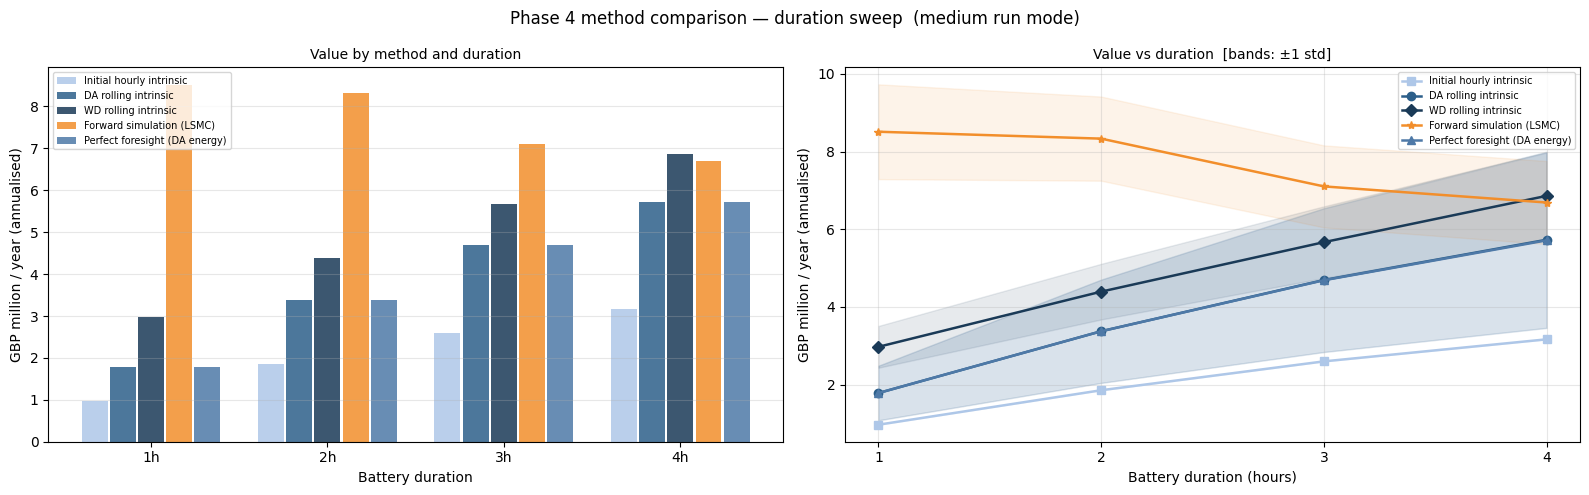


LSMC value (£m/year) by method and duration:
                                 1h    2h    3h    4h
method                                               
Initial hourly intrinsic       0.97  1.86  2.60  3.17
DA rolling intrinsic           1.79  3.38  4.69  5.73
WD rolling intrinsic           2.97  4.39  5.67  6.86
Forward simulation (LSMC)      8.51  8.33  7.10  6.69
Perfect foresight (DA energy)  1.79  3.37  4.69  5.71


In [4]:
METHODS = [
    'Initial hourly intrinsic',
    'DA rolling intrinsic',
    'WD rolling intrinsic',
    'Forward simulation (LSMC)',
    'Perfect foresight (DA energy)',
]
METHOD_COLOURS = {
    'Initial hourly intrinsic':      '#aec7e8',
    'DA rolling intrinsic':          '#2c5f8a',
    'WD rolling intrinsic':          '#1a3a57',
    'Forward simulation (LSMC)':     '#f28e2b',
    'Perfect foresight (DA energy)': '#4e79a7',
}
METHOD_MARKERS = {
    'Initial hourly intrinsic':      's',
    'DA rolling intrinsic':          'o',
    'WD rolling intrinsic':          'D',
    'Forward simulation (LSMC)':     '*',
    'Perfect foresight (DA energy)': '^',
}

durations_avail = sorted(df_cmp['duration_h'].unique()) if len(df_cmp) else []

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 4 method comparison — duration sweep  (medium run mode)', fontsize=12)

# ── Left: grouped bar by duration ────────────────────────────────────────────
ax = axes[0]
n_dur = len(durations_avail)
n_met = len(METHODS)
x     = np.arange(n_dur)
width = 0.8 / n_met

for i, method in enumerate(METHODS):
    sub  = df_cmp[df_cmp['method'] == method].set_index('duration_h')
    vals = [float(sub.loc[d, 'value_gbp_annualized_m']) if d in sub.index else np.nan for d in durations_avail]
    offsets = x + i * width - (n_met - 1) * width / 2
    ax.bar(offsets, vals, width * 0.92,
           color=METHOD_COLOURS.get(method, '#888888'), alpha=0.85, label=method)

ax.set_xticks(x)
ax.set_xticklabels([f'{d:g}h' for d in durations_avail])
ax.set_xlabel('Battery duration')
ax.set_ylabel('GBP million / year (annualised)')
ax.set_title('Value by method and duration', fontsize=10)
ax.legend(fontsize=7, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# ── Right: line chart — value vs duration ────────────────────────────────────
ax = axes[1]
for method in METHODS:
    sub = df_cmp[df_cmp['method'] == method].sort_values('duration_h')
    if sub.empty:
        continue
    col = METHOD_COLOURS.get(method, '#888888')
    mrk = METHOD_MARKERS.get(method, 'o')
    ax.plot(sub['duration_h'], sub['value_gbp_annualized_m'],
            marker=mrk, linewidth=1.8, markersize=6, color=col, label=method)
    if 'p5_ann_m' in sub.columns and 'p95_ann_m' in sub.columns:
        ax.fill_between(sub['duration_h'],
                        sub['p5_ann_m'], sub['p95_ann_m'],
                        alpha=0.10, color=col)

ax.set_xlabel('Battery duration (hours)')
ax.set_ylabel('GBP million / year (annualised)')
ax.set_title('Value vs duration  [bands: ±1 std]', fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
if durations_avail:
    ax.set_xticks(durations_avail)

fig.tight_layout()
out_cmp_png = PROCESSED / 'phase4_all_durations_comparison.png'
fig.savefig(out_cmp_png, dpi=140, bbox_inches='tight')
print(f'Saved: {out_cmp_png}')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
if len(df_cmp):
    pivot = df_cmp.pivot_table(
        index='method', columns='duration_h',
        values='value_gbp_annualized_m', aggfunc='first',
    ).reindex(METHODS)
    pivot.columns = [f'{c:g}h' for c in pivot.columns]
    print('\nLSMC value (£m/year) by method and duration:')
    print(pivot.round(2).to_string())


## 5  LSMC Attribution Across Durations


Saved: g:\My Drive\Research\bess_project\data\processed\phase4_all_durations_attribution.png


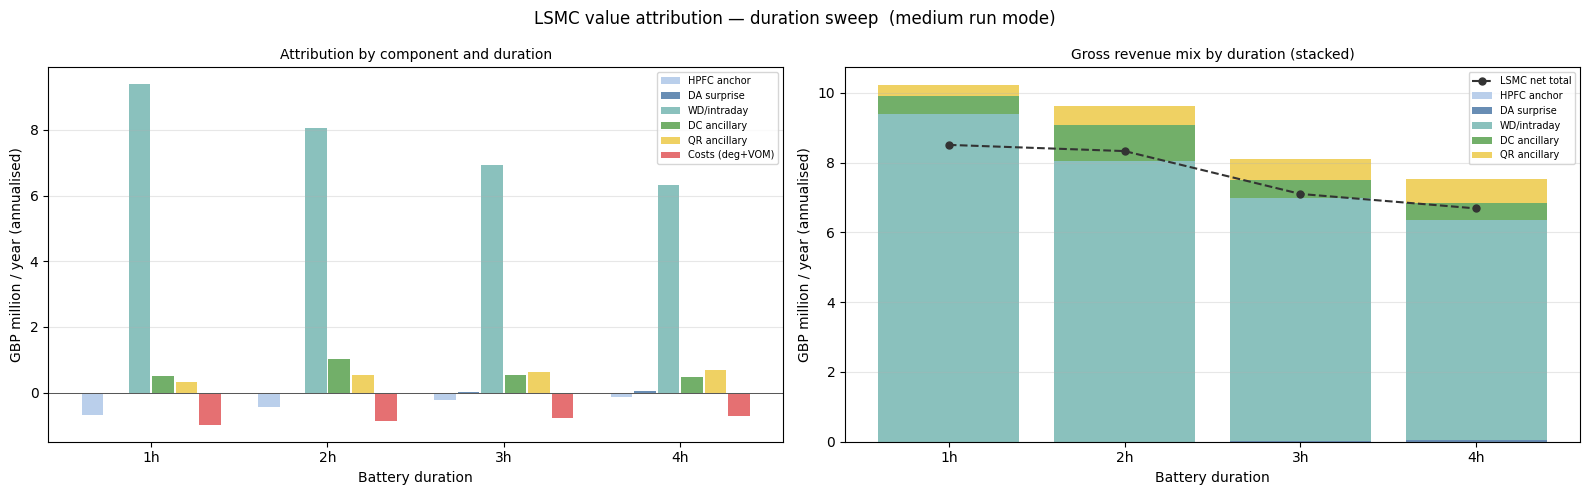


Attribution share (% of gross revenue):
                 1h     2h     3h     4h
component                               
HPFC anchor    -9.1   -5.7   -3.7   -2.1
DA surprise    -0.7   -0.1    0.4    0.7
WD/intraday   124.6  107.9  109.9  105.8
DC ancillary    6.8   13.7    8.4    8.1
QR ancillary    4.3    7.2    9.7   11.6


In [5]:
COMPONENTS_ORD = ['HPFC anchor', 'DA surprise', 'WD/intraday', 'DC ancillary', 'QR ancillary', 'Costs (deg+VOM)']
COMP_COLOURS = {
    'HPFC anchor':      '#aec7e8',
    'DA surprise':      '#4e79a7',
    'WD/intraday':      '#76b7b2',
    'DC ancillary':     '#59a14f',
    'QR ancillary':     '#edc948',
    'Costs (deg+VOM)':  '#e15759',
}

if df_attr.empty:
    print('No attribution data loaded — skipping chart')
else:
    dur_list = sorted(df_attr['duration_h'].unique())
    x        = np.arange(len(dur_list))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('LSMC value attribution — duration sweep  (medium run mode)', fontsize=12)

    # ── Left: grouped bar — component mean by duration ────────────────────────
    ax = axes[0]
    n_comp = len(COMPONENTS_ORD)
    width  = 0.8 / n_comp

    for i, comp in enumerate(COMPONENTS_ORD):
        sub  = df_attr[df_attr['component'] == comp].set_index('duration_h')
        vals = [float(sub.loc[d, 'mean_m']) if d in sub.index else np.nan for d in dur_list]
        offsets = x + i * width - (n_comp - 1) * width / 2
        ax.bar(offsets, vals, width * 0.92,
               color=COMP_COLOURS.get(comp, '#888'), alpha=0.85, label=comp)

    ax.axhline(0, color='#555', linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{d:g}h' for d in dur_list])
    ax.set_xlabel('Battery duration')
    ax.set_ylabel('GBP million / year (annualised)')
    ax.set_title('Attribution by component and duration', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    # ── Right: stacked bar — gross revenue mix by duration ────────────────────
    ax    = axes[1]
    gross = [c for c in COMPONENTS_ORD if c != 'Costs (deg+VOM)']
    bot   = np.zeros(len(dur_list))

    for comp in gross:
        sub  = df_attr[df_attr['component'] == comp].set_index('duration_h')
        vals = np.array([
            max(float(sub.loc[d, 'mean_m']), 0.0) if d in sub.index else 0.0
            for d in dur_list
        ])
        ax.bar(x, vals, bottom=bot,
               color=COMP_COLOURS[comp], alpha=0.85, label=comp)
        bot += vals

    # Overlay total LSMC line
    if len(df_cmp):
        lsmc_sub = df_cmp[df_cmp['method'] == 'Forward simulation (LSMC)'].set_index('duration_h')
        totals   = [float(lsmc_sub.loc[d, 'value_gbp_annualized_m']) if d in lsmc_sub.index else np.nan
                    for d in dur_list]
        ax.plot(x, totals, 'o--', color='#333333', linewidth=1.5, markersize=5, label='LSMC net total')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{d:g}h' for d in dur_list])
    ax.set_xlabel('Battery duration')
    ax.set_ylabel('GBP million / year (annualised)')
    ax.set_title('Gross revenue mix by duration (stacked)', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    fig.tight_layout()
    out_attr_png = PROCESSED / 'phase4_all_durations_attribution.png'
    fig.savefig(out_attr_png, dpi=140, bbox_inches='tight')
    print(f'Saved: {out_attr_png}')
    plt.show()

    # Attribution share table
    print('\nAttribution share (% of gross revenue):')
    attr_pivot = df_attr[df_attr['component'].isin(gross)].pivot_table(
        index='component', columns='duration_h',
        values='pct_of_gross', aggfunc='first',
    ).reindex([c for c in COMPONENTS_ORD if c in gross])
    attr_pivot.columns = [f'{c:g}h' for c in attr_pivot.columns]
    print(attr_pivot.round(1).to_string())


## 6  Save Combined Outputs


In [6]:
if len(df_cmp):
    out = PROCESSED / 'phase4_all_durations_comparison.csv'
    df_cmp.to_csv(out, index=False)
    print(f'Saved: {out}')

    out = PROCESSED / 'phase4_all_durations_comparison.json'
    df_cmp.to_json(out, orient='records', indent=2)
    print(f'Saved: {out}')

if len(df_attr):
    out = PROCESSED / 'phase4_all_durations_attribution.csv'
    df_attr.to_csv(out, index=False)
    print(f'Saved: {out}')

    out = PROCESSED / 'phase4_all_durations_attribution.json'
    df_attr.to_json(out, orient='records', indent=2)
    print(f'Saved: {out}')

print('\nAll outputs saved.')


Saved: g:\My Drive\Research\bess_project\data\processed\phase4_all_durations_comparison.csv
Saved: g:\My Drive\Research\bess_project\data\processed\phase4_all_durations_comparison.json
Saved: g:\My Drive\Research\bess_project\data\processed\phase4_all_durations_attribution.csv
Saved: g:\My Drive\Research\bess_project\data\processed\phase4_all_durations_attribution.json

All outputs saved.
